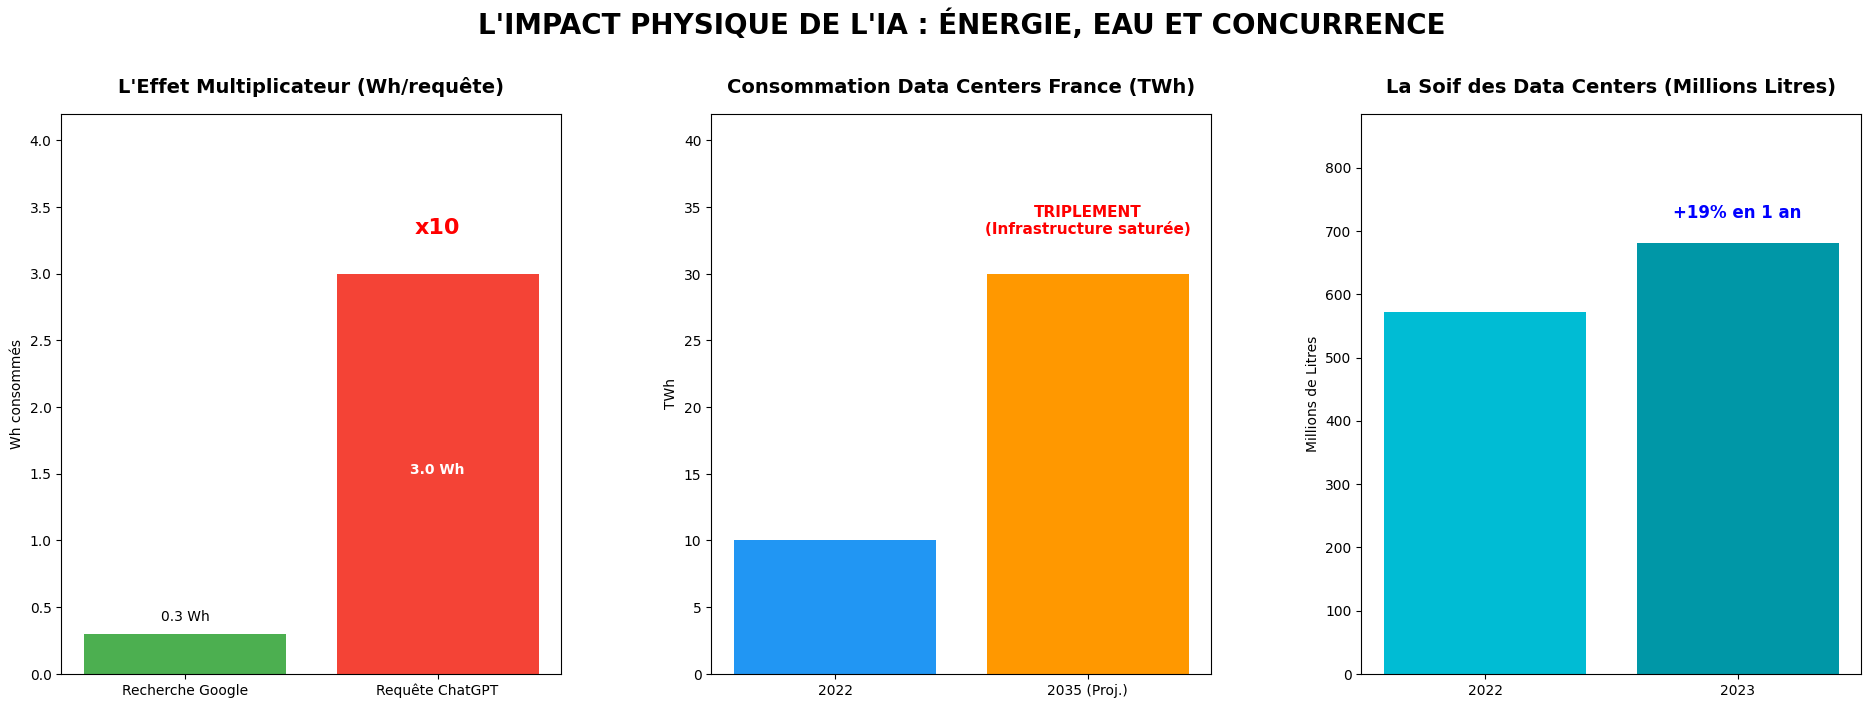

---

### ANALYSE DES DONNEES (Généré depuis le CSV)

- **Consommation Mondiale Data Centers & IA** (Source : AIE (Agence Internationale de l'Énergie)) : 
  > La consommation pourrait doubler en 4 ans (1050 TWh en 2026). (Valeur clé : 460.0 TWh)

- **Densité énergétique par rack (Serveur)** (Source : AIE (Agence Internationale de l'Énergie)) : 
  > Explosion de la densité : Standard (5-10 kW) vs IA NVIDIA (100 kW). (Valeur clé : 100.0 kW)

- **Part des Data Centers en Irlande** (Source : AIE (Agence Internationale de l'Énergie)) : 
  > Va passer à 32% en 2026 (Exemple de saturation du réseau). (Valeur clé : 17.0 %)

...

- **Conso eau par conversation (20-50 questions)** (Source : UC Riverside (Étude Scientifique)) : 
  > Une bouteille d'eau (500ml) 'consommée' à chaque conversation. (Valeur clé : 0.5 Litres)

- **Eau prélevée par Data Centers France** (Source : Arcep (France)) : 
  > Hausse brutale de +19% par rapport à 2022. (Valeur clé : 681.0 Millions de Litres)

- **Hausse consommation eau mondiale** (Source : Microsoft (Rapport RSE)) : 
  > Hausse liée directement au développement de l'IA. (Valeur clé : 34.0 %)

- **Barrière à l'entrée (Énergie)** (Source : Autorité de la concurrence) : 
  > Les géants monopolisent l'accès au nucléaire/renouvelable; PME bloquées. (Valeur clé : nan Analyse)

- **IA Frugale** (Source : Autorité de la concurrence) : 
  > Seul levier pour permettre la concurrence et l'innovation des petits acteurs. (Valeur clé : nan Concept)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import numpy as np
import os

# --- ÉTAPE 1 : CRÉATION DU FICHIER DE DONNÉES ---
csv_content = """Source,Catégorie,Sujet,Valeur,Unité,Année_Réf,Note
AIE (Agence Internationale de l'Énergie),Électricité (Monde),Consommation Mondiale Data Centers & IA,460,TWh,2022,"La consommation pourrait doubler en 4 ans (1050 TWh en 2026)."
AIE (Agence Internationale de l'Énergie),Électricité (Infrastructure),Densité énergétique par rack (Serveur),100,kW,2024,"Explosion de la densité : Standard (5-10 kW) vs IA NVIDIA (100 kW)."
AIE (Agence Internationale de l'Énergie),Électricité (Pays),Part des Data Centers en Irlande,17,%,2022,"Va passer à 32% en 2026 (Exemple de saturation du réseau)."
AIE (Agence Internationale de l'Énergie),Énergie (Unitaire),Consommation par requête ChatGPT vs Google,3,Wh,2024,"1 requête ChatGPT (3 Wh) = 10x une recherche Google (0.3 Wh)."
RTE (France),Électricité (France),Consommation Data Centers France,10,TWh,2022,"2% de la conso nationale. Prévision de triplement d'ici 2035."
UC Riverside (Étude Scientifique),Eau (Modèle),Eau consommée pour entraîner GPT-3,700000,Litres,2020,"Equivalent à la fabrication de 370 BMW."
UC Riverside (Étude Scientifique),Eau (Usage),Conso eau par conversation (20-50 questions),0.5,Litres,2023,"Une bouteille d'eau (500ml) 'consommée' à chaque conversation."
Arcep (France),Eau (France),Eau prélevée par Data Centers France,681,Millions de Litres,2023,"Hausse brutale de +19% par rapport à 2022."
Microsoft (Rapport RSE),Eau (Entreprise),Hausse consommation eau mondiale,34,%,2022,"Hausse liée directement au développement de l'IA."
Autorité de la concurrence,Marché,Barrière à l'entrée (Énergie),N/A,Analyse,2024,"Les géants monopolisent l'accès au nucléaire/renouvelable; PME bloquées."
Autorité de la concurrence,Stratégie,IA Frugale,N/A,Concept,2024,"Seul levier pour permettre la concurrence et l'innovation des petits acteurs."
"""

file_path = '/content/water.csv'
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(csv_content)

# --- ÉTAPE 2 : VISUALISATION ---

def visualiser_impact_ia_clean():
    # Chargement
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        return

    # Configuration de la figure avec plus d'espace en haut
    fig, axes = plt.subplots(1, 3, figsize=(20, 8)) # Hauteur augmentée à 8

    # Titre général remonté
    plt.suptitle("L'IMPACT PHYSIQUE DE L'IA : ÉNERGIE, EAU ET CONCURRENCE",
                 fontsize=20, fontweight='bold', y=0.98)

    # --- GRAPHIQUE 1 : LE CHOC UNITAIRE ---
    row_chatgpt = df[df['Sujet'].str.contains("Consommation par requête", case=False, na=False)]
    val_gpt = 3.0
    if not row_chatgpt.empty:
        try: val_gpt = float(row_chatgpt.iloc[0]['Valeur'])
        except: val_gpt = 3.0

    items_1 = ['Recherche Google', 'Requête ChatGPT']
    values_1 = [0.3, val_gpt]

    axes[0].bar(items_1, values_1, color=['#4caf50', '#f44336'])
    axes[0].set_title("L'Effet Multiplicateur (Wh/requête)", fontsize=14, fontweight='bold', pad=15)
    axes[0].set_ylabel("Wh consommés")

    # CORRECTION : Augmenter la limite Y pour éviter le chevauchement
    axes[0].set_ylim(0, val_gpt * 1.4)

    axes[0].annotate('x10', xy=(1, val_gpt), xytext=(1, val_gpt + 0.3),
                     ha='center', fontsize=16, fontweight='bold', color='red')
    axes[0].text(0, 0.3 + 0.1, "0.3 Wh", ha='center')
    axes[0].text(1, val_gpt/2, f"{val_gpt} Wh", ha='center', color='white', fontweight='bold')


    # --- GRAPHIQUE 2 : L'URGENCE NATIONALE ---
    row_rte = df[df['Source'].str.contains("RTE", na=False)]
    val_2022 = float(row_rte.iloc[0]['Valeur']) if not row_rte.empty else 10.0
    val_2035 = val_2022 * 3

    years_2 = ['2022', '2035 (Proj.)']
    values_2 = [val_2022, val_2035]

    axes[1].bar(years_2, values_2, color=['#2196f3', '#ff9800'])
    axes[1].set_title("Consommation Data Centers France (TWh)", fontsize=14, fontweight='bold', pad=15)
    axes[1].set_ylabel("TWh")

    # CORRECTION : Augmenter la limite Y
    axes[1].set_ylim(0, val_2035 * 1.4)

    axes[1].annotate('TRIPLEMENT\n(Infrastructure saturée)',
                     xy=(1, val_2035), xytext=(1, val_2035 + 3), # Texte aligné au-dessus
                     ha='center', fontsize=11, fontweight='bold', color='red')


    # --- GRAPHIQUE 3 : L'EAU ---
    row_arcep = df[df['Source'].str.contains("Arcep", na=False)]
    val_eau_2023 = float(row_arcep.iloc[0]['Valeur']) if not row_arcep.empty else 681.0
    val_eau_2022 = val_eau_2023 / 1.19

    years_3 = ['2022', '2023']
    values_3 = [val_eau_2022, val_eau_2023]

    axes[2].bar(years_3, values_3, color=['#00bcd4', '#0097a7'])
    axes[2].set_title("La Soif des Data Centers (Millions Litres)", fontsize=14, fontweight='bold', pad=15)
    axes[2].set_ylabel("Millions de Litres")

    # CORRECTION : Augmenter la limite Y
    axes[2].set_ylim(0, val_eau_2023 * 1.3)

    axes[2].annotate('+19% en 1 an',
                     xy=(1, val_eau_2023), xytext=(1, val_eau_2023 + 40),
                     ha='center', fontsize=12, fontweight='bold', color='blue')

    # Ajustement des marges globales
    plt.subplots_adjust(top=0.85, bottom=0.15, left=0.05, right=0.95, wspace=0.3)
    plt.show()

    # --- AFFICHAGE DES EXPLICATIONS (SANS EMOTICONES) ---
    display(Markdown("---"))
    display(Markdown("### ANALYSE DES DONNEES (Généré depuis le CSV)"))

    for index, row in df.iterrows():
        source = row['Source']
        sujet = row['Sujet']
        note = row['Note']
        valeur = row['Valeur']
        unite = row['Unité']

        # Affichage propre avec puces standards
        texte = f"- **{sujet}** (Source : {source}) : \n  > {note} (Valeur clé : {valeur} {unite})"
        display(Markdown(texte))

if __name__ == "__main__":
    visualiser_impact_ia_clean()